In [35]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

In [39]:
# Set the data directory
var_name = "geopotential_500"
data_dir = "/glade/work/bgong/gencast_neuralGCM_crps_ssr/gencast_neuralGCM_crps_ssr/ngcm_results_2019_2024/"
file_pattern = f"ngcm_2019_2024_crps_ssr_{var_name}*"
gencast_dir = "/glade/work/bgong/gencast_neuralGCM_crps_ssr/gencast_neuralGCM_crps_ssr/gencast_results_2019_2024/"
gencast_file = f"gencast_2019_2024_crps_ssr_{var_name}.nc"
# Find files matching the pattern
file_path = glob.glob(os.path.join(data_dir, file_pattern))


In [29]:
file_path

[]

In [30]:
gencast_path = os.path.join(gencast_dir, gencast_file)

Found 1 file(s):
  ngcm_2019_2024_crps_ssr_geopotential_500.nc

NGCM Dataset info:
<xarray.Dataset> Size: 4kB
Dimensions:               (prediction_timedelta: 180)
Coordinates:
  * prediction_timedelta  (prediction_timedelta) int64 1kB 6 12 18 ... 1074 1080
Data variables:
    crps                  (prediction_timedelta) float64 1kB ...
    ssr                   (prediction_timedelta) float32 720B ...
lens of crps: (46,)

GenCast file found: gencast_2019_2024_crps_ssr_geopotential_500.nc
GenCast Dataset info:
<xarray.Dataset> Size: 2kB
Dimensions:               (prediction_timedelta: 90)
Coordinates:
  * prediction_timedelta  (prediction_timedelta) int64 720B 12 24 ... 1068 1080
Data variables:
    crps                  (prediction_timedelta) float64 720B ...
    ssr                   (prediction_timedelta) float32 360B ...
time_days_ngcm: <xarray.DataArray 'prediction_timedelta' (prediction_timedelta: 180)> Size: 1kB
array([ 0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,  2.25

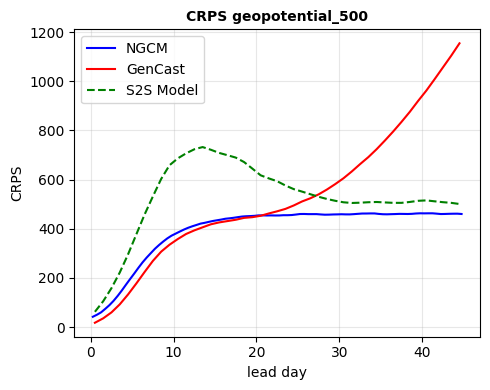

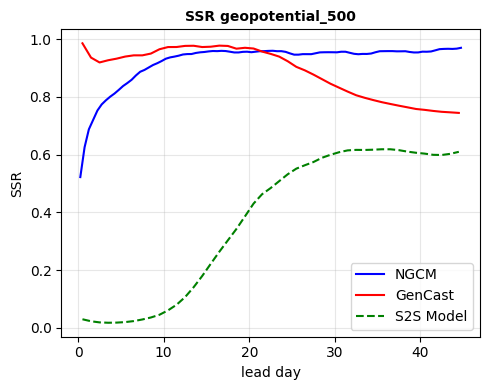

In [40]:
if not file_path:
    print(f"No files found matching pattern: {file_pattern}")
    print(f"In directory: {data_dir}")
else:
    print(f"Found {len(file_path)} file(s):")
    for f in file_path:
        print(f"  {os.path.basename(f)}")

# Load NGCM dataset
if file_path:
    ds_ngcm = xr.open_dataset(file_path[0],decode_cf=False)
    print("\nNGCM Dataset info:")
    print(ds_ngcm)

# Load GenCast dataset
gencast_path = os.path.join(gencast_dir, gencast_file)

#Load the S2S model dataset
crps_var_path = "/glade/work/bgong/benchmark-dev/hpc_templates/{var_name}_crps.npy".format(var_name=var_name)
sst_var_path =  "/glade/work/bgong/benchmark-dev/hpc_templates/{var_name}_sst.npy".format(var_name=var_name)
crps_var =  np.load(crps_var_path)
sst_var = np.load(sst_var_path)
print("lens of crps:",crps_var.shape)


if os.path.exists(gencast_path):
    ds_gencast = xr.open_dataset(gencast_path,decode_cf=False)
    print(f"\nGenCast file found: {gencast_file}")
    print("GenCast Dataset info:")
    print(ds_gencast)
else:
    print(f"\nGenCast file not found: {gencast_path}")
    ds_gencast = None

# Create separate plots if at least one dataset is available
if file_path or ds_gencast is not None:
    
    # Plot 1: CRPS Comparison
    plt.figure(figsize=(5, 4))
    
    if file_path and 'crps' in ds_ngcm.variables:
        # NGCM CRPS
        time_days_ngcm = ds_ngcm['prediction_timedelta'] / 24.0
        crps_data_ngcm = ds_ngcm['crps']
        if crps_data_ngcm.ndim > 1:
            crps_mean_ngcm = crps_data_ngcm.mean(dim=[d for d in crps_data_ngcm.dims if d != 'prediction_timedelta'])
        else:
            crps_mean_ngcm = crps_data_ngcm
        
        print("time_days_ngcm:",time_days_ngcm)
        plt.plot(time_days_ngcm[::2], crps_mean_ngcm[::2], 'b-', linewidth=1.5, label='NGCM')
    
    if ds_gencast is not None and 'crps' in ds_gencast.variables:
        # GenCast CRPS
        time_days_gencast = ds_gencast['prediction_timedelta'] / 24.0
        crps_data_gencast = ds_gencast['crps']
        if crps_data_gencast.ndim > 1:
            crps_mean_gencast = crps_data_gencast.mean(dim=[d for d in crps_data_gencast.dims if d != 'prediction_timedelta'])
        else:
            crps_mean_gencast = crps_data_gencast

        plt.plot(time_days_gencast[::2], crps_mean_gencast[::2], 'r-', linewidth=1.5, label='GenCast')

    
    if crps_var is not None:
        lead_days = np.arange(1, len(crps_var) + 1)
        if var_name == "total_precipitation_24h":
            plt.plot(time_days_gencast[::2], crps_var[1:]*1000, 'g--', linewidth=1.5, label='S2S Model')
        else:
            plt.plot(time_days_gencast[::2], crps_var[1:], 'g--', linewidth=1.5, label='S2S Model')
        

    plt.title(f'CRPS {var_name}', fontsize=10, fontweight='bold')
    plt.xlabel('lead day')
    plt.ylabel('CRPS')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'crps_{var_name}.png', dpi=600)

    plt.show()
    # Plot 2: SSR Comparison
    plt.figure(figsize=(5, 4))
    
    if file_path and 'ssr' in ds_ngcm.variables:
        # NGCM SSR
        ssr_data_ngcm = ds_ngcm['ssr']
        if ssr_data_ngcm.ndim > 1:
            ssr_mean_ngcm = ssr_data_ngcm.mean(dim=[d for d in ssr_data_ngcm.dims if d != 'prediction_timedelta'])
        else:
            ssr_mean_ngcm = ssr_data_ngcm
        
        plt.plot(time_days_ngcm[::2], ssr_mean_ngcm[::2], 'b-', linewidth=1.5, label='NGCM')
    
    if ds_gencast is not None and 'ssr' in ds_gencast.variables:
        # GenCast SSR
        ssr_data_gencast = ds_gencast['ssr']
        if ssr_data_gencast.ndim > 1:
            ssr_mean_gencast = ssr_data_gencast.mean(dim=[d for d in ssr_data_gencast.dims if d != 'prediction_timedelta'])
        else:
            ssr_mean_gencast = ssr_data_gencast
        
        plt.plot(time_days_gencast[::2], ssr_mean_gencast[::2], '-r', linewidth=1.5, label='GenCast')

    if sst_var is not None:
        plt.plot(time_days_gencast[::2], sst_var[1:], 'g--', linewidth=1.5, label='S2S Model')
    plt.title(f'SSR {var_name}', fontsize=10, fontweight='bold')
    plt.xlabel('lead day')
    plt.ylabel('SSR')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'ssr_{var_name}.png', dpi=600)
    plt.show()


In [41]:
ens_mean_path = "/glade/work/bgong/benchmark-dev/hpc_templates/geopotential_500_ens_mean.npy"
ens_mean =  np.load(ens_mean_path)

array([[[[48420.242, 48420.594, 48420.91 , ..., 48419.402, 48419.68 ,
          48419.938],
         [48390.06 , 48390.746, 48391.613, ..., 48388.227, 48388.746,
          48389.383],
         [48364.44 , 48365.81 , 48367.35 , ..., 48360.973, 48362.004,
          48363.16 ],
         ...,
         [52417.906, 52414.035, 52409.93 , ..., 52428.836, 52425.34 ,
          52421.742],
         [52573.6  , 52571.344, 52569.07 , ..., 52579.992, 52577.914,
          52575.79 ],
         [52709.383, 52708.57 , 52707.836, ..., 52711.742, 52710.945,
          52710.164]],

        [[48196.93 , 48197.906, 48198.914, ..., 48193.863, 48194.875,
          48195.887],
         [48241.4  , 48243.445, 48245.46 , ..., 48235.215, 48237.285,
          48239.348],
         [48284.098, 48287.184, 48290.215, ..., 48274.62 , 48277.773,
          48280.902],
         ...,
         [54052.07 , 54044.086, 54036.023, ..., 54075.227, 54067.6  ,
          54059.9  ],
         [54110.57 , 54105.992, 54101.29 , ..., 54